In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("C_labeled.csv")
data.columns = data.columns.str.strip()  # 列名の空白を削除

a=len(data)
print(a)
# すべての列を数値型に変換し、無効な値をNaNに置き換え
data = data.apply(pd.to_numeric, errors='coerce')

# NaNを含む行を削除
data_cleaned = data.dropna()

GRtiming=data_cleaned['GRQ2timing']
LAStiming=data_cleaned['LASQ1timing']
TDiff=LAStiming-GRtiming

114499


In [216]:
# data_cleaned = pd.read_csv("C_labeled.csv")

In [217]:
data_cleaned

,run,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
0,2025,20,-303.5990,0.009948,-4.884480,0.008808,479270.00,238.178,-21.7587,0.047277,65.05220,0.038042,478897.00,106.5260
1,2025,72,475.7480,0.067137,-60.950600,0.012590,1756.92,499.558,-211.7930,0.101364,39.21570,0.090030,1980.29,118.4190
2,2025,79,76.6026,0.007484,18.890300,-0.002013,146236.00,226.542,181.9780,0.077720,-206.60000,0.268428,146322.00,151.6260
3,2025,85,254.6680,0.048382,-21.434000,0.005113,280165.00,202.365,153.1550,0.141902,38.85800,0.009935,280248.00,145.1320
4,2025,97,-275.7720,0.017044,-24.185200,0.004193,417741.00,232.766,93.0143,-0.133045,-25.46280,0.011841,417888.00,174.1380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114494,2026,5946544,-13.4523,0.047025,5.605090,-0.000939,338506.00,453.412,-201.3150,-0.111289,-5.49648,0.013874,338473.00,130.1970
114495,2026,5946580,-222.1470,-0.033318,-23.460500,0.003556,51493.10,234.663,213.6160,-0.066629,-15.45550,-0.013431,51403.90,151.3770
114496,2026,5946695,155.4010,-0.009337,-9.766170,-0.000115,173640.00,210.909,515.9360,0.071106,-2.32119,0.052418,173786.00,93.2285
114497,2026,5946721,146.3520,0.020858,0.349176,0.000105,76978.60,264.607,-494.1000,0.022044,68.83930,0.025245,77068.10,64.2126


In [218]:
xdp=data_cleaned['GRX']
adp=data_cleaned['GRA']
ydp=data_cleaned['GRY']
bdp=data_cleaned['GRB']
GRQ2=data_cleaned['GRQ2charge']

In [219]:
correct=data_cleaned[
    (TDiff != 0) & (xdp!=-9999) & (ydp!=-9999)
]

In [220]:
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

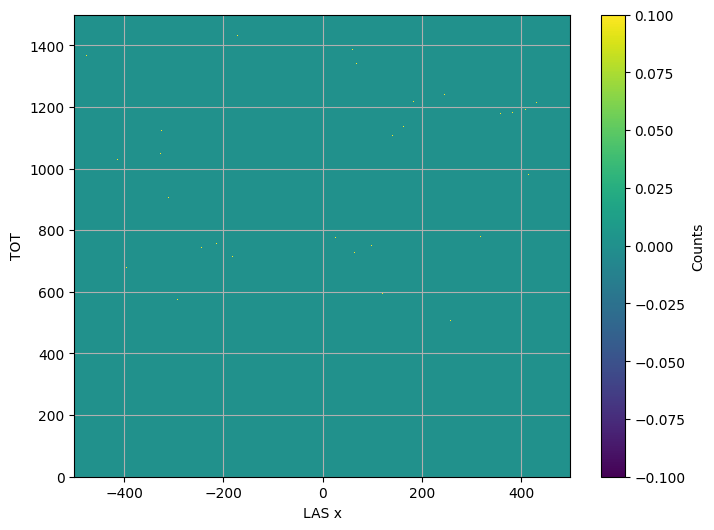

In [221]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=correct['GRX']
y_axis_variable=correct['GRQ2timing']
#hist range
x_axis_range_min=-500
x_axis_range_max=500
y_axis_range_min=0
y_axis_range_max=1500
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('LAS x')
ax.set_ylabel('TOT')
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

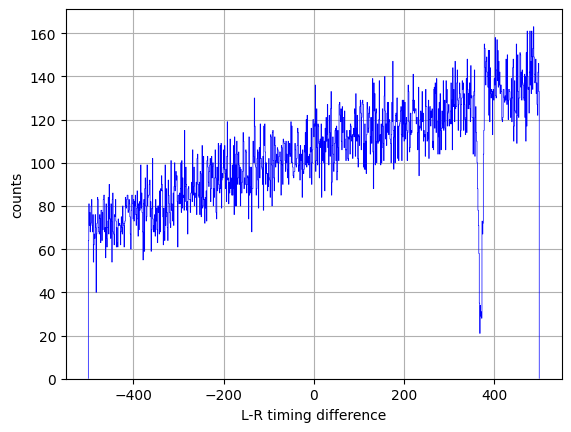

In [222]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=correct['GRX']
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('L-R timing difference')
ax.set_ylabel('counts')

In [223]:
print(len(data_cleaned))
print(len(correct))

114499
114462


Text(0, 0.5, 'counts')

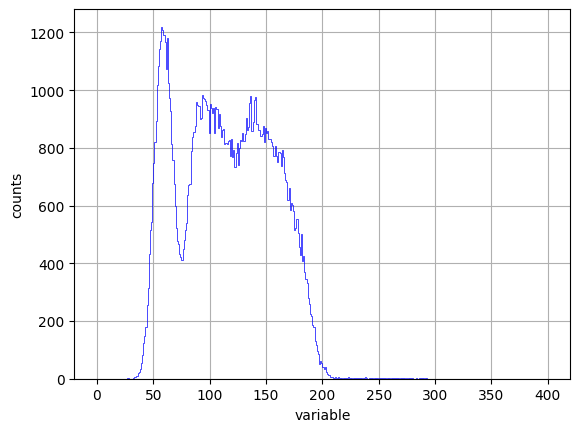

In [224]:
TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TOT
#hist range
range_min=0
range_max=400
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

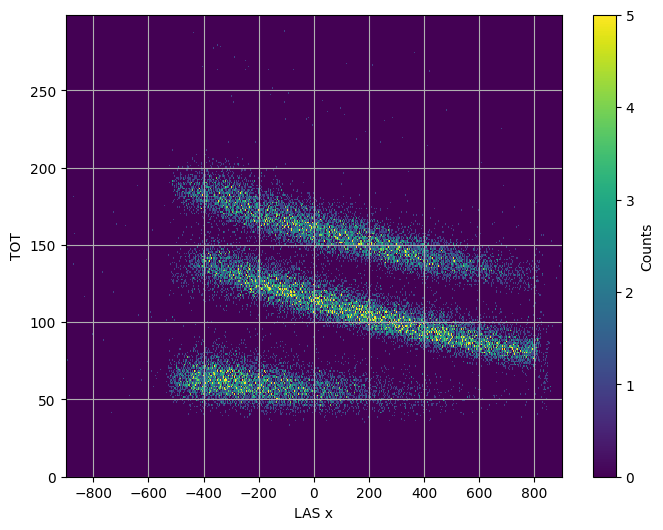

In [225]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Lx
y_axis_variable=TOT
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('LAS x')
ax.set_ylabel('TOT')
ax.grid()

plt.show()

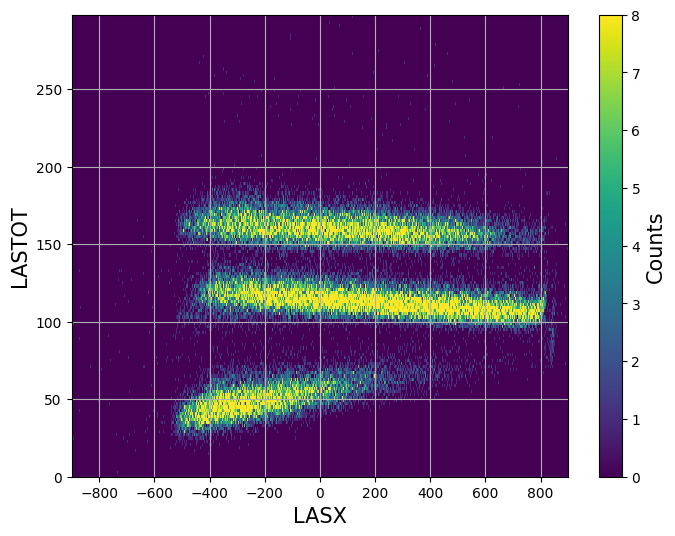

In [226]:
TOTc=TOT+0.0430496*Lx-1.3842e-5*(Lx**2)

from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=Lx
y_axis_variable=TOTc
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=2
y_bin_width=2
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 3)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize=15)

# 軸範囲とグリッド
ax.set_xlabel('LASX', fontsize=15)
ax.set_ylabel('LASTOT', fontsize=15)
ax.grid()

plt.show()

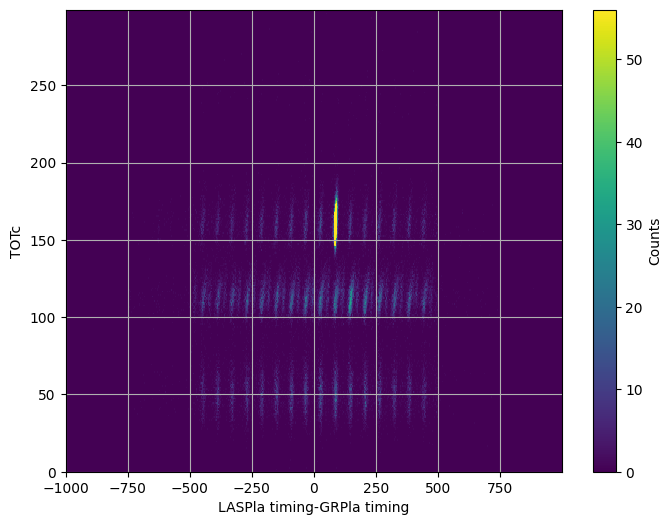

In [227]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=TDiff
y_axis_variable=TOTc
#hist range
x_axis_range_min=-1000
x_axis_range_max=1000
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=2
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 5)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('LASPla timing-GRPla timing')
ax.set_ylabel('TOTc')
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

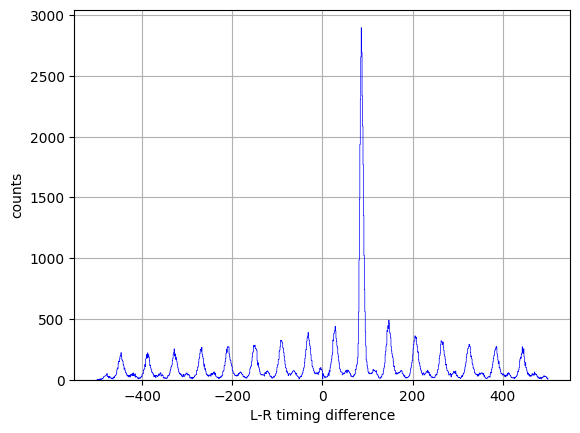

In [228]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TDiff
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('L-R timing difference')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 2740.650 ± 67.617
Mean: 86.920 ± 0.112
Sigma: 3.916 ± 0.112


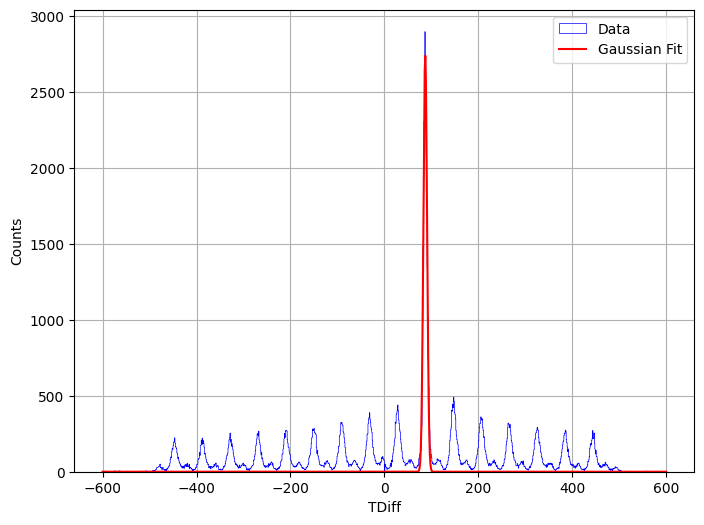

In [229]:
variable = TDiff
# Histogram range
hist_range_min = -600
hist_range_max = 600
# Bin width
bin_width = 1
# Fit range
fit_range_min = 50
fit_range_max = 150
# Initial parameters for the Gaussian
Amp = 3000
mean = 100
sigma = 10
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('TDiff')
ax.set_ylabel('Counts')
ax.legend()

Text(0, 0.5, 'counts')

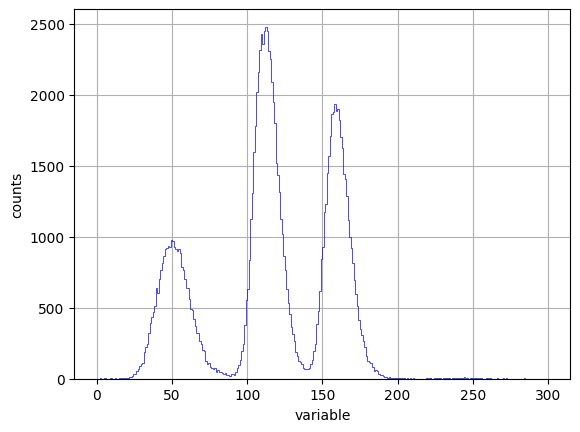

In [230]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TOTc
#hist range
range_min=0
range_max=300
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 1930.654 ± 20.352
Mean: 159.506 ± 0.098
Sigma: 7.495 ± 0.110


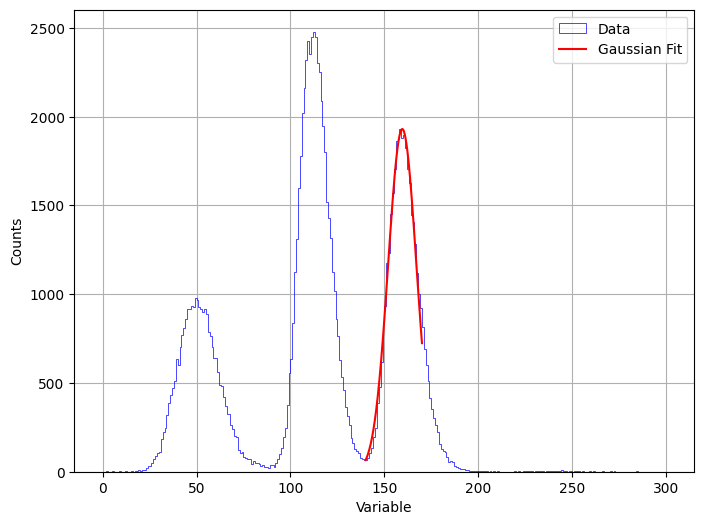

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Input
##############################################################
# Fitする変数
fit_variable = TOTc
# Histogram range
hist_range_min = 0
hist_range_max = 300
# Bin width
bin_width = 1
# Fit range
fit_range_min = 140
fit_range_max = 170
# Initial parameters for the Gaussian
Amp = 5000
mean = 145
sigma = 5
# Fit parameter boundaries
bound_min = [0, 140, 0]
bound_max = [np.inf, 160, 50]
##############################################################

# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(fit_variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(fit_range_min, fit_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(fit_variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

plt.show()

In [232]:
# アルファゲートを設定
alpha_gated=correct[
    (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>130) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<170)
]
# alpha_gated=correct[
#     (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>190) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<250)
# ]

TOT_alpha=alpha_gated['LASTOT']
Lx_alpha=alpha_gated['LASX']
GRtiming_alpha=alpha_gated['GRQ2timing']
LAStiming_alpha=alpha_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

Text(0, 0.5, 'counts')

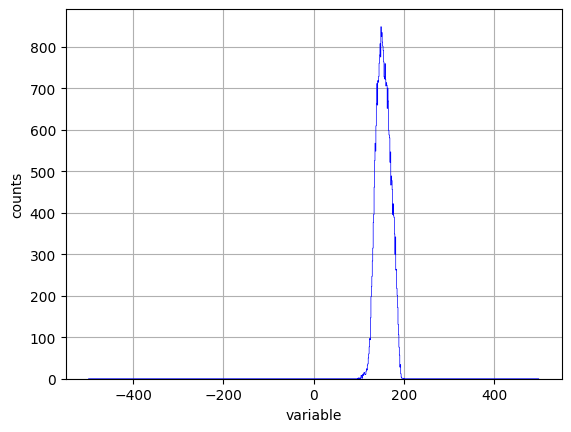

In [233]:
#アルファゲートかけてコインシデンスとる
#綺麗にアクシデンタル減らせたのを確認

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable = alpha_gated['LASTOT']
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')
# ax.set_yscale('log')

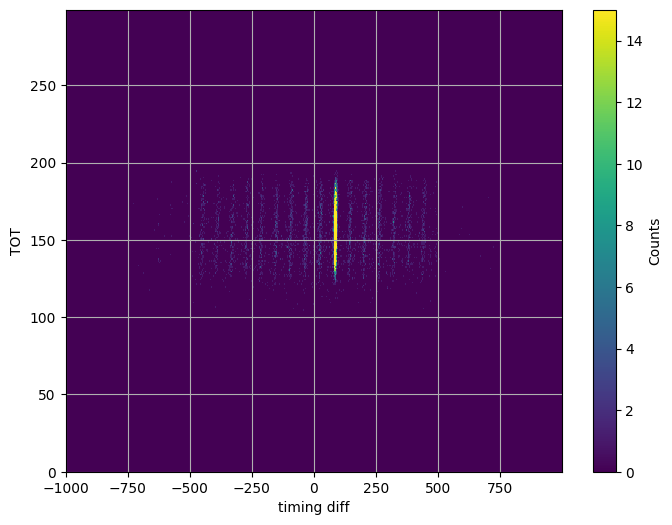

In [234]:

from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=TDiff_alpha
y_axis_variable=TOT_alpha
#hist range
x_axis_range_min=-1000
x_axis_range_max=1000
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 5)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('timing diff')
ax.set_ylabel('TOT')
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

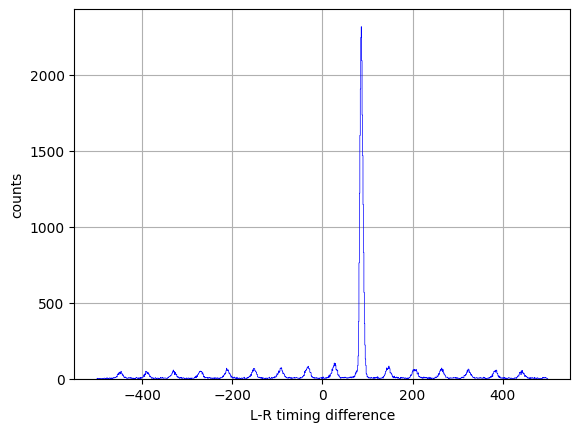

In [235]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TDiff_alpha
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('L-R timing difference')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 2249.155 ± 25.742
Mean: 86.471 ± 0.045
Sigma: 3.440 ± 0.045


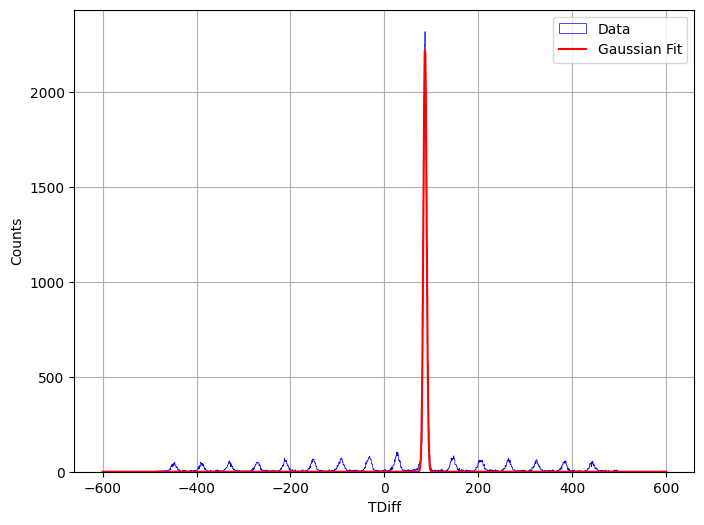

In [236]:
variable = TDiff_alpha
# Histogram range
hist_range_min = -600
hist_range_max = 600
# Bin width
bin_width = 1
# Fit range
fit_range_min = 50
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 2000
mean = 75
sigma = 20
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('TDiff')
ax.set_ylabel('Counts')
ax.legend()

In [237]:
#両方ゲート

GRQ2_track=correct['GRQ2charge']

# both_gated=alpha_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
both_gated=alpha_gated[
    (GRQ2_track>190) & (GRQ2_track<234)
]

GRtiming_both=both_gated['GRQ2timing']
LAStiming_both=both_gated['LASQ1timing']
TDiff_both=LAStiming_both-GRtiming_both

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_20361/2621369320.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  both_gated=alpha_gated[


Text(0, 0.5, 'counts')

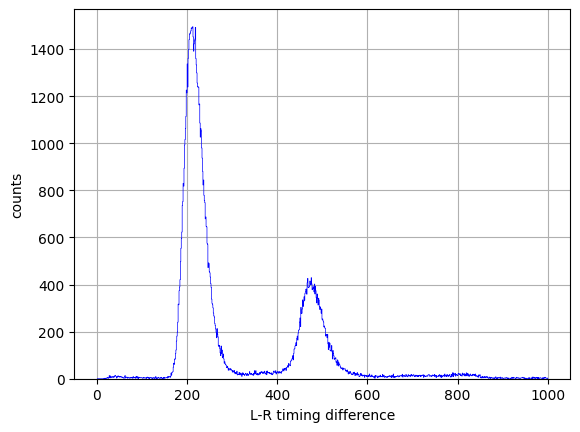

In [238]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=GRQ2_track
#hist range
range_min=0
range_max=1000
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('L-R timing difference')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 1543.020 ± 20.342
Mean: 86.353 ± 0.052
Sigma: 3.396 ± 0.052


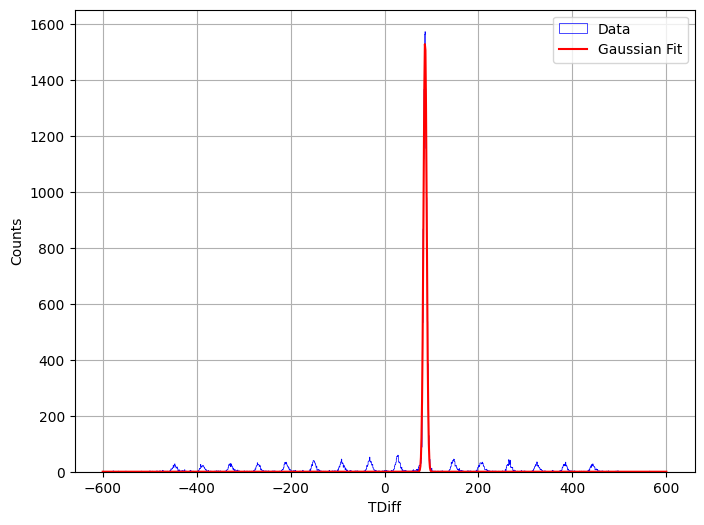

In [239]:
variable = TDiff_both
# Histogram range
hist_range_min = -600
hist_range_max = 600
# Bin width
bin_width = 1
# Fit range
fit_range_min = 50
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 1000
mean = 75
sigma = 10
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('TDiff')
ax.set_ylabel('Counts')
ax.legend()